# От Score товара к выбору итоговой ассортиментной матрицы

Продолжение [`../Кластеризация точек продаж`](../Кластеризация%20точек%20продаж): там точки сети разбиты на
сегменты, здесь для каждого сегмента строится и выбирается конкретная товарная матрица.

Шаги:

1. посчитать **Score** каждого товара внутри его **юнита** - группы взаимозаменяемых товаров;
2. разделить юниты на классы **A/B/C** по вкладу в Score сегмента;
3. сгенерировать несколько **кандидатов на матрицу** двумя методами и выбрать лучший, сравнив каждого с
   действующей матрицей по деньгам: остатки по нормативу запаса, выручка, прибыль;
4. **проверить на отложенных неделях**, что выбранная матрица действительно лучше, и сравнить автосегменты с
   другими способами разбить сеть на группы.

**Про данные.** Расчёт идёт на синтетических данных из общей базы [`../synthetic_data`](../synthetic_data):
справочник лекарств - из открытого реестра ЖНВЛП, продажи и действующая матрица сгенерированы, сегменты точек -
результат ноутбука кластеризации. Цифры не отражают реальный бизнес.

## Импорт библиотек и параметры

In [1]:
import os
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import expon

pd.options.display.max_columns = 100
pd.options.display.float_format = '{:,.2f}'.format
sns.set_theme(style='whitegrid', font_scale=0.95)
plt.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
DB_PATH = os.environ.get('SYNTH_DB', '../synthetic_data/synthetic_projects.duckdb')

# Те же бизнес-фильтры чеков, что в кластеризации
EXCLUDED_SALE_TYPES = ('Опт', 'Маркетплейс')
MIN_SHELF_LIFE_MONTHS = 6

# Поправка Score на ценовой уровень товара: сегменту «эконом» важнее дешёвый товар, «премиум» - дорогой
PRICE_ADJUSTMENT = {
    'эконом':   {'low': 1.2, 'medium': 1.0, 'high': 0.8},
    'медиум -': {'low': 1.1, 'medium': 1.1, 'high': 0.9},
    'медиум':   {'low': 1.0, 'medium': 1.1, 'high': 1.0},
    'медиум +': {'low': 0.9, 'medium': 1.1, 'high': 1.1},
    'премиум':  {'low': 0.8, 'medium': 1.0, 'high': 1.2},
}

# Границы накопительной доли для ABC-классификации юнитов внутри сегмента
ABC_LOWER_BOUND = 0.5   # до этой накопительной доли Score - класс A
ABC_UPPER_BOUND = 0.9   # до этой - класс B, дальше - класс C

# Кандидаты ABC-порогов: для класса юнита (A/B/C) - минимальная доля товара в Score своего юнита,
# плюс минимальный Score юнита для класса C (в рублях на точку за период)
ABC_THRESHOLD_CANDIDATES = pd.DataFrame([
    {"method": "мягкий",  "a": 0.05, "b": 0.10, "c": 0.20, "s_u": 0.0},
    {"method": "средний", "a": 0.10, "b": 0.15, "c": 0.25, "s_u": 50.0},
    {"method": "строгий", "a": 0.15, "b": 0.25, "c": 0.35, "s_u": 150.0},
])

# Строгость экспоненциального отбора подбирается плавно: 30 значений λ от почти «всё продаваемое» до «только лидеры».
# Чем больше λ, тем строже отбор. ABC-пороги считаются для сравнения, выбор идёт по шкале λ.
LAMBDA_GRID = list(dict.fromkeys(float(f'{x:.2g}') for x in np.geomspace(0.01, 2, 30)))
LAMBDAS_SHOW = [0.05, 0.2, 1.0]   # для графика формы порога

# Защищённые позиции входят в матрицу независимо от Score: минимальный ассортимент и собственная марка
PROTECT_MIN_ASSORTMENT = True
PROTECT_OWN_BRAND = True

# Доля продаж исключённого товара, которая переходит на оставшиеся товары того же юнита (покупатель берёт аналог)
SUBSTITUTION_RATE = 0.5

# Норматив запаса товара матрицы в аптеке (в штуках):
#   средний запас = max(выкладка, страховой запас + половина объёма поставки),
#   страховой запас = z * sqrt(спрос в день * (срок поставки + интервал заказа)) - спрос случайный (Пуассон),
#   объём поставки = спрос в день * интервал заказа.
DISPLAY_UNITS = 2        # минимум на полке, даже если товар почти не продаётся
LEAD_DAYS = 2            # срок поставки, дней
REVIEW_DAYS = 7          # заказ раз в неделю
SERVICE_Z = 1.65         # уровень сервиса 95%

# Стоимость денег в остатках - для одного итогового числа «прибыль минус стоимость запаса»
CAPITAL_COST_YEAR = 0.20

# Юнит делится ещё и по фасовке (число доз в упаковке): пачка на 10 и на 100 таблеток - разные юниты.
# Категории фасовки - те же, что в ценовом анализе кластеризации. Нештучные формы по фасовке не делятся.
UNIT_BY_PACK = os.environ.get('UNIT_BY_PACK', '1') == '1'
PACK_BINS = [(1, '1'), (4, '2-4'), (8, '5-8'), (12, '9-12'), (20, '13-20'), (30, '21-30'),
             (50, '31-50'), (100, '51-100'), (np.inf, '100+')]

# Эксперимент: сколько случайных разбиений сети усреднять
N_RANDOM = 5
SEED = 2026

## Данные

Период чеков делится пополам: **первая половина - обучение** (по ней кластеризация построила сегменты, а здесь
считаются Score, варианты матриц и выбор варианта), **вторая - отложенная проверка**: на ней выбранные матрицы
оцениваются по продажам, которых расчёт не видел.

In [3]:
con = duckdb.connect(DB_PATH)


def query(sql: str, params=None) -> pd.DataFrame:
    return con.execute(sql, params or []).df()


tables = set(query("SELECT table_schema || '.' || table_name AS t FROM information_schema.tables").t)
assert 'results.store_segments' in tables, 'Сначала выполните ноутбук кластеризации точек: он пишет сегменты в базу'

period = query("SELECT MIN(Date) AS d0, MAX(Date) AS d1 FROM pharmacy.cheques").iloc[0]
DATE_FROM, DATA_END = pd.Timestamp(period.d0), pd.Timestamp(period.d1)
TRAIN_DAYS = ((DATA_END - DATE_FROM).days + 1) // 2
TRAIN_END = DATE_FROM + pd.Timedelta(days=TRAIN_DAYS - 1)
TEST_DAYS = (DATA_END - TRAIN_END).days
print(f'Обучение: {DATE_FROM:%d.%m.%Y} - {TRAIN_END:%d.%m.%Y} ({TRAIN_DAYS} дн.), '
      f'проверка: {TRAIN_END + pd.Timedelta(days=1):%d.%m.%Y} - {DATA_END:%d.%m.%Y} ({TEST_DAYS} дн.)')

stores = query("""
    SELECT s.TradePointId, s.segment, s.price_level, st.CurrentCategory, a.archetype
    FROM results.store_segments s
    JOIN pharmacy.stores st USING (TradePointId)
    JOIN pharmacy.store_archetypes a USING (TradePointId)
""").set_index('TradePointId')
print(f'{len(stores)} точек в {stores.segment.nunique()} сегментах')

Обучение: 02.03.2026 - 29.03.2026 (28 дн.), проверка: 30.03.2026 - 26.04.2026 (28 дн.)
234 точек в 13 сегментах


In [4]:
# продажи «точка × товар» отдельно за обучение и за проверку
sp = query(f"""
    SELECT c.TradePointId, c.apCode,
           CASE WHEN c.Date <= ? THEN 'train' ELSE 'test' END AS period,
           SUM(c.Amount)                  AS units,
           SUM(c.Sum_Fact)                AS revenue,
           SUM(c.Sum_Fact - c.Sum_Purch)  AS profit
    FROM pharmacy.cheques c
    JOIN pharmacy.products p USING (apCode)
    WHERE c.SaleType NOT IN {EXCLUDED_SALE_TYPES}
      AND c.ShelfLifeMonths >= {MIN_SHELF_LIFE_MONTHS}
      AND p.product_class <> 'Нетоварные позиции'
      AND c.TradePointId IN (SELECT TradePointId FROM results.store_segments)
    GROUP BY 1, 2, 3
""", [TRAIN_END])
train = sp[sp.period == 'train'].drop(columns='period')
test = sp[sp.period == 'test'].drop(columns='period')

products = query("""
    SELECT p.apCode, p.name, p.mnn, p.form_group, p.form_name, p.subcategory, p.doses_in_pack, p.is_min_assortment, p.is_own_brand,
           p.base_price, COALESCE(t.price_tier, 'medium') AS price_tier
    FROM pharmacy.products p LEFT JOIN results.product_price_tiers t USING (apCode)
    WHERE p.product_class <> 'Нетоварные позиции'
""")
# юнит - группа взаимозаменяемых товаров: МНН + лекформа, для нелекарственного ассортимента - подкатегория + вид
products['Unit'] = np.where(products.mnn.notna(), products.mnn + ', ' + products.form_group,
                            products.subcategory + ', ' + products.form_name)
if UNIT_BY_PACK:
    pack = products.doses_in_pack.map(lambda d: None if pd.isna(d) else next(l for u, l in PACK_BINS if d <= u))
    products['Unit'] = products.Unit + pack.map(lambda b: '' if b is None else f', {b} шт.')
print(f"Юнитов: {products.Unit.nunique():,} ({'с делением' if UNIT_BY_PACK else 'без деления'} по фасовке)")

# закупочная цена штуки: по чекам обучения, запасной вариант - базовая цена без условной наценки
cost = train.groupby('apCode').apply(lambda g: (g.revenue - g.profit).sum() / g.units.sum())
products['cost'] = products.apCode.map(cost).fillna(products.base_price / 1.35)
products = products.set_index('apCode')

# действующая матрица: у каждой точки - матрица её текущей категории A-E
fact_pairs = stores[['CurrentCategory']].reset_index().merge(
    query("SELECT CurrentCategory, apCode FROM pharmacy.matrix_fact"), on='CurrentCategory')[['TradePointId', 'apCode']]
fact_pairs = fact_pairs[fact_pairs.apCode.isin(products.index)]
print(f'Строк продаж: обучение {len(train):,}, проверка {len(test):,}; '
      f'в действующих матрицах в среднем {len(fact_pairs) / len(stores):,.0f} позиций на точку')

Юнитов: 697 (с делением по фасовке)


Строк продаж: обучение 215,246, проверка 214,981; в действующих матрицах в среднем 1,918 позиций на точку


## Функции

In [5]:
def norm_units(daily_demand):
    """Средний запас товара в точке по нормативу, штук: выкладка или страховой запас + половина поставки."""
    safety = SERVICE_Z * np.sqrt(daily_demand * (LEAD_DAYS + REVIEW_DAYS))
    return np.maximum(DISPLAY_UNITS, safety + daily_demand * REVIEW_DAYS / 2)


def evaluate(pairs: pd.DataFrame, sales: pd.DataFrame) -> dict:
    """Деньги матрицы: pairs - какие товары в матрице каждой точки (TradePointId, apCode), sales - продажи
    «точка × товар» за оцениваемый период.
    - выручка и прибыль: продажи товаров матрицы + SUBSTITUTION_RATE продаж исключённых товаров, если в той же
      точке остался товар того же юнита;
    - остатки: норматив запаса каждой позиции матрицы по спросу периода обучения, по закупочной цене."""
    m = pairs.assign(in_m=True)
    s = sales.merge(m, on=['TradePointId', 'apCode'], how='left').fillna({'in_m': False})
    s['Unit'] = s.apCode.map(products.Unit)
    kept = pairs.assign(Unit=pairs.apCode.map(products.Unit))[['TradePointId', 'Unit']].drop_duplicates().assign(kept=True)
    s = s.merge(kept, on=['TradePointId', 'Unit'], how='left').fillna({'kept': False})
    inc, moved = s.in_m.astype(bool), (~s.in_m.astype(bool)) & s.kept.astype(bool)

    d = pairs.merge(train[['TradePointId', 'apCode', 'units']], on=['TradePointId', 'apCode'], how='left')
    stock = (norm_units(d.units.fillna(0) / TRAIN_DAYS) * d.apCode.map(products.cost)).sum()
    return {'stock_rub': stock,
            'revenue': s.revenue[inc].sum() + SUBSTITUTION_RATE * s.revenue[moved].sum(),
            'profit': s.profit[inc].sum() + SUBSTITUTION_RATE * s.profit[moved].sum(),
            'positions': len(pairs) / pairs.TradePointId.nunique()}

In [6]:
def classify_units_abc(units: pd.DataFrame, lower_bound: float, upper_bound: float) -> pd.DataFrame:
    """
    Делит юниты на классы A/B/C по накопительной доле их Score внутри группы точек: сортируем юниты по убыванию
    доли, берём накопительную сумму - первые юниты, дающие вместе до `lower_bound` Score, это класс A,
    до `upper_bound` - класс B, остальное - класс C.
    """
    units = units.sort_values(['grp', 'share_by_cluster'], ascending=[True, False]).copy()
    units['cum_share'] = units.groupby('grp')['share_by_cluster'].cumsum()
    units['Status'] = np.select([units.cum_share <= lower_bound, units.cum_share <= upper_bound], ['A', 'B'], 'C')
    return units


def matrix_sign_by_abc_threshold(df, a_bound, b_bound, c_bound, score_min) -> pd.Series:
    """Входит ли товар в матрицу при заданной комбинации ABC-порогов - разный порог по нормированному скору
    товара в зависимости от класса его юнита, плюс минимальный скор юнита для класса C."""
    return (((df.Status == 'A') & (df.score_norm_ap >= a_bound))
            | ((df.Status == 'B') & (df.score_norm_ap >= b_bound))
            | ((df.Status == 'C') & (df.score_norm_ap >= c_bound) & (df.score_unit > score_min)))


def matrix_sign_by_exponential_bound(df, lam) -> pd.Series:
    """
    Вероятностная альтернатива ABC-порогам: граница по CDF экспоненциального распределения от веса юнита
    (`share_rel` - доля юнита в Score группы относительно крупнейшего юнита, от 0 до 1): чем весомее юнит,
    тем ниже порог для товаров внутри него. λ регулирует строгость.
    """
    return df.score_norm_ap > expon.cdf(1 - df.share_rel, scale=1 / lam)

In [7]:
VARIANTS = [(r['method'], r) for _, r in ABC_THRESHOLD_CANDIDATES.iterrows()] + \
           [(f'экспоненциальный (λ={lam:g})', lam) for lam in LAMBDA_GRID]
EXP_VARIANTS = [name for name, _ in VARIANTS if name.startswith('эксп')]


def build_candidates(groups: pd.Series):
    """Score, ABC-классы и все варианты матрицы для разбиения точек на группы (groups: точка -> группа).
    Всё считается по периоду обучения. Возвращает таблицу «группа × товар» с признаками вариантов и юниты."""
    g = train.assign(grp=train.TradePointId.map(groups))
    df = g.groupby(['grp', 'apCode'], as_index=False)[['revenue']].sum()
    df = df.join(products[['Unit', 'price_tier', 'is_min_assortment', 'is_own_brand']], on='apCode')
    n_stores = groups.value_counts()
    level = stores.price_level.groupby(groups).agg(lambda x: x.mode().iloc[0])   # ценовой уровень группы
    adj = [PRICE_ADJUSTMENT[level[c]][t] for c, t in zip(df.grp, df.price_tier)]
    df['score'] = df.revenue / df.grp.map(n_stores) * np.array(adj)

    units = df.groupby(['grp', 'Unit'], as_index=False)['score'].sum().rename(columns={'score': 'score_unit'})
    units['share_by_cluster'] = units.score_unit / units.groupby('grp').score_unit.transform('sum')
    units = classify_units_abc(units, ABC_LOWER_BOUND, ABC_UPPER_BOUND)

    df = df.merge(units[['grp', 'Unit', 'score_unit', 'share_by_cluster', 'Status']], on=['grp', 'Unit'])
    df['score_norm_ap'] = (df.score / df.score_unit).fillna(0)
    df['share_rel'] = df.share_by_cluster / df.groupby('grp').share_by_cluster.transform('max')
    protected = (PROTECT_MIN_ASSORTMENT & df.is_min_assortment) | (PROTECT_OWN_BRAND & df.is_own_brand)
    for name, prm in VARIANTS:
        sign = (matrix_sign_by_abc_threshold(df, prm['a'], prm['b'], prm['c'], prm['s_u']) if isinstance(prm, pd.Series)
                else matrix_sign_by_exponential_bound(df, prm))
        df[name] = sign | (protected & (df.score > 0))
    return df, units


def to_pairs(groups: pd.Series, df: pd.DataFrame, variant: str) -> pd.DataFrame:
    """Матрица группы разворачивается на все точки группы."""
    sel = df.loc[df[variant], ['grp', 'apCode']]
    return groups.rename('grp').reset_index().merge(sel, on='grp')[['TradePointId', 'apCode']]


def compare_variants(groups, df, sales):
    """Все варианты и действующая матрица на одних продажах; разница с действующей матрицей."""
    rows = [{'вариант': 'факт', **evaluate(fact_pairs, sales)}]
    rows += [{'вариант': name, **evaluate(to_pairs(groups, df, name), sales)} for name, _ in VARIANTS]
    res = pd.DataFrame(rows)
    for m in ['stock_rub', 'revenue', 'profit', 'positions']:
        res[f'diff_{m}'] = res[m] - res.loc[0, m]
    return res


def choose(res):
    """Правило выбора по шкале строгости λ: из вариантов, которые не увеличивают остатки, - вариант с
    максимальной прибылью."""
    cand = res[res['вариант'].isin(EXP_VARIANTS)]
    ok = cand[cand.diff_stock_rub <= 0]
    return (ok if len(ok) else cand).sort_values('profit', ascending=False).iloc[0]['вариант']

## Score товара и ABC-классы юнитов

**Юнит** - группа взаимозаменяемых товаров: для лекарств это МНН + лекарственная форма («ибупрофен, таблетки»),
для нелекарственного ассортимента - подкатегория + вид товара. **Score** - выручка товара в сегменте на одну
точку с поправкой на ценовой уровень: в эконом-сегменте дешёвый товар своей подкатегории получает бонус, дорогой -
штраф, в премиальном наоборот.

In [8]:
seg_groups = stores.segment
cand, units = build_candidates(seg_groups)
n_stores = seg_groups.value_counts()
print(f'{len(cand):,} пар «сегмент-товар», {cand.Unit.nunique():,} юнитов')
cand.join(products.name, on='apCode')[['grp', 'name', 'Unit', 'price_tier', 'revenue', 'score']] \
    .sort_values('score', ascending=False).head(8)

33,407 пар «сегмент-товар», 697 юнитов


,grp,name,Unit,price_tier,revenue,score
19591,Крупные · универсальный · медиум +,Гелиоопти тонометр (медицинская техника),"Медицинская техника, тонометр",high,"3,234,697.17","177,908.34"
16467,"Крупные · мать и дитя, косметика · медиум +",Гелиоопти тонометр (медицинская техника),"Медицинская техника, тонометр",high,"2,012,045.50","170,250.00"
17249,Крупные · универсальный · медиум +,ГЕРПОСТАД таблетки 400 мг №80,"Ацикловир, таблетки, 51-100 шт.",medium,"2,433,687.04","133,852.79"
4826,"Большие · мать и дитя, косметика · медиум +",Гелиоопти тонометр (медицинская техника),"Медицинская техника, тонометр",high,"1,165,758.09","128,233.39"
2232,"Большие · косметика, БАД · премиум",Гелиоопти тонометр (медицинская техника),"Медицинская техника, тонометр",high,"1,426,717.86","95,114.52"
16405,"Крупные · мать и дитя, косметика · медиум +",Неоактив ингалятор (медицинская техника),"Медицинская техника, ингалятор",high,"1,071,056.78","90,627.88"
19528,Крупные · универсальный · медиум +,Неоактив ингалятор (медицинская техника),"Медицинская техника, ингалятор",high,"1,528,207.43","84,051.41"
16107,"Крупные · мать и дитя, косметика · медиум +",Экобэби тонометр (медицинская техника),"Медицинская техника, тонометр",high,"991,739.27","83,916.40"


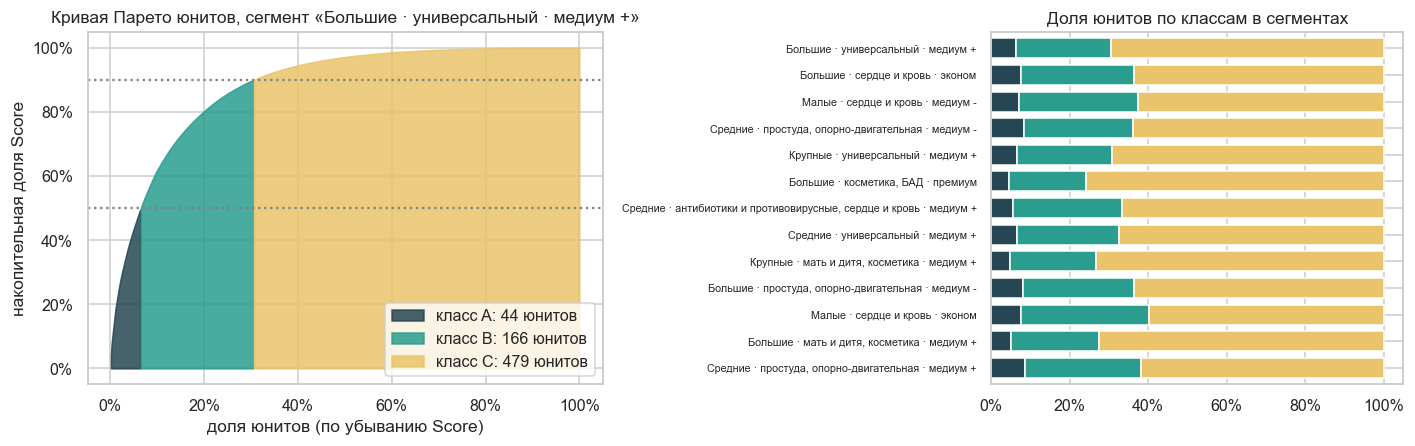

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={'width_ratios': [1.25, 1]})
biggest = n_stores.idxmax()
u = units[units.grp == biggest].reset_index(drop=True)
x = np.arange(1, len(u) + 1) / len(u)
colors = {'A': '#264653', 'B': '#2a9d8f', 'C': '#e9c46a'}
for status, part in u.groupby('Status'):
    axes[0].fill_between(x[part.index], 0, part.cum_share, color=colors[status], alpha=.85, label=f'класс {status}: {len(part)} юнитов')
axes[0].axhline(ABC_LOWER_BOUND, color='grey', ls=':'); axes[0].axhline(ABC_UPPER_BOUND, color='grey', ls=':')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1)); axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[0].set(title=f'Кривая Парето юнитов, сегмент «{biggest}»', xlabel='доля юнитов (по убыванию Score)',
            ylabel='накопительная доля Score'); axes[0].legend(loc='lower right')
share = units.groupby('grp').Status.value_counts(normalize=True).unstack()[['A', 'B', 'C']].loc[n_stores.sort_values().index]
share.plot.barh(stacked=True, color=[colors[s] for s in 'ABC'], ax=axes[1], width=.75, legend=False)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[1].set(title='Доля юнитов по классам в сегментах', xlabel='', ylabel=''); axes[1].tick_params(axis='y', labelsize=7)
plt.tight_layout(); plt.show()

## Кандидаты на матрицу и выбор

Основной метод - **экспоненциальный порог**: минимум доли товара в Score юнита плавно зависит от веса юнита, а
общая строгость задаётся параметром λ. Строгость подбирается плавно - 30 значений λ, от почти всего продаваемого до
одних лидеров, - и из них выбирается лучший вариант. Три набора **ABC-порогов** (у каждого класса юнита свой
минимум) показаны для сравнения. Защищённые позиции (минимальный ассортимент, собственная марка) входят в матрицу
при любом Score.

Каждый вариант сравнивается с действующей матрицей по деньгам **на неделях обучения**. Остатки считаются по
нормативу запаса для каждой пары «точка × товар матрицы»: редкий товар стоит минимум выкладки, ходовой -
страховой запас и половину недельной поставки.

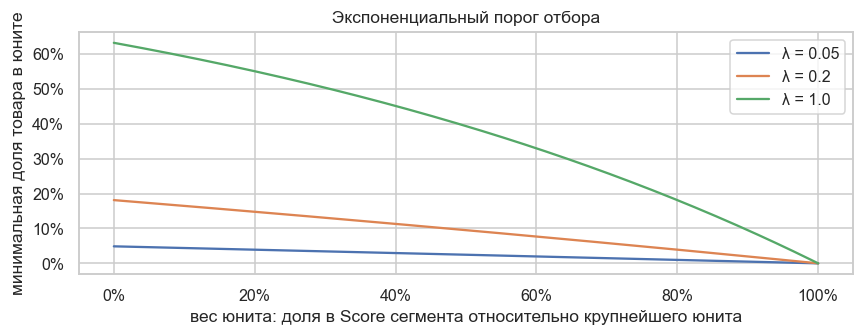

In [10]:
share_grid = np.linspace(0, 1, 200)
plt.figure(figsize=(8, 3.2))
for lam in LAMBDAS_SHOW:
    plt.plot(share_grid, expon.cdf(1 - share_grid, scale=1 / lam), label=f'λ = {lam}')
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(1, decimals=0))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1))
plt.xlabel('вес юнита: доля в Score сегмента относительно крупнейшего юнита'); plt.ylabel('минимальная доля товара в юните')
plt.title('Экспоненциальный порог отбора'); plt.legend(); plt.tight_layout(); plt.show()

In [11]:
res_train = compare_variants(seg_groups, cand, train)
selected = choose(res_train)
res_train.style.format({c: '{:,.0f}' for c in res_train.columns if c != 'вариант'})

,вариант,stock_rub,revenue,profit,positions,diff_stock_rub,diff_revenue,diff_profit,diff_positions
0,факт,"665,175,391","530,321,083","135,175,608","1,918",0,0,0,0
1,мягкий,"707,499,349","582,678,149","147,856,049","1,895","42,323,959","52,357,066","12,680,441",-23
2,средний,"639,609,815","562,420,709","142,836,830","1,680","-25,565,576","32,099,626","7,661,222",-238
3,строгий,"575,915,677","537,822,897","136,697,899","1,471","-89,259,713","7,501,814","1,522,291",-447
4,экспоненциальный (λ=0.01),"883,088,780","609,126,490","154,583,941","2,561","217,913,389","78,805,407","19,408,333",643
5,экспоненциальный (λ=0.012),"877,738,885","608,732,931","154,481,036","2,536","212,563,494","78,411,848","19,305,428",618
6,экспоненциальный (λ=0.014),"871,429,526","608,231,619","154,352,567","2,509","206,254,135","77,910,536","19,176,959",591
7,экспоненциальный (λ=0.017),"862,342,931","607,514,482","154,174,329","2,473","197,167,540","77,193,399","18,998,721",556
8,экспоненциальный (λ=0.021),"850,844,034","606,462,590","153,905,672","2,432","185,668,644","76,141,507","18,730,064",515
9,экспоненциальный (λ=0.025),"841,177,484","605,317,173","153,613,213","2,396","176,002,094","74,996,090","18,437,605",479


C:\Users\User\AppData\Local\Temp\ipykernel_1948\3520829774.py:13: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  axes[0].legend(loc='lower right'); plt.tight_layout(); plt.show()


C:\Users\User\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


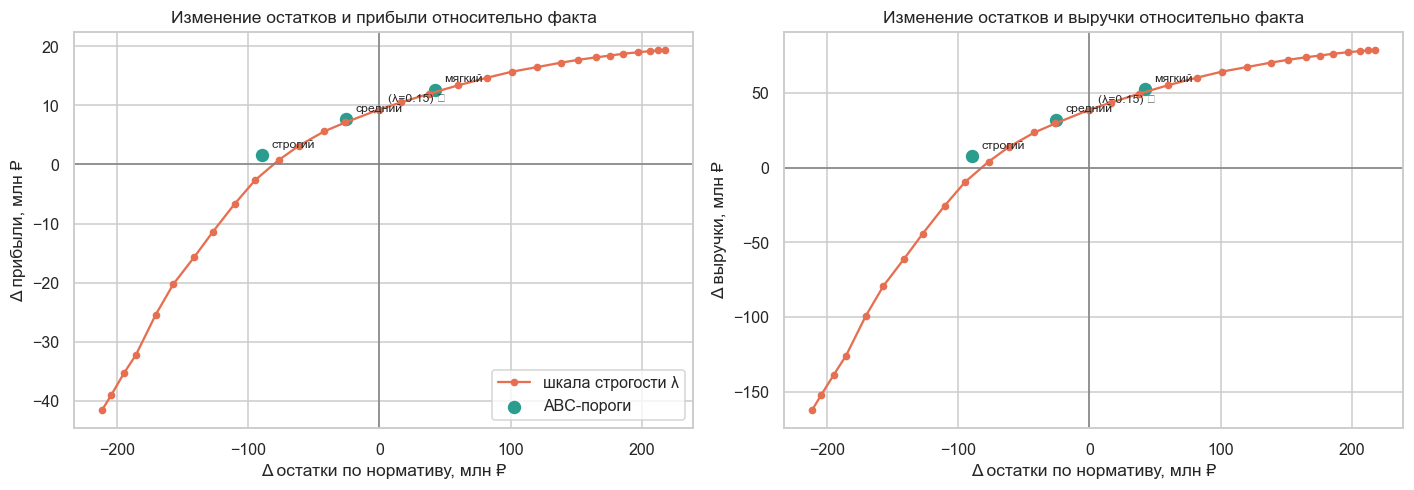

Выбран вариант: экспоненциальный (λ=0.15) (правило: максимум прибыли без роста остатков, недели обучения)
  остатки -0.3 млн ₽ (-0%), выручка +38.6 млн ₽ (+7.3%), прибыль +9.3 млн ₽ (+6.9%), позиций на точку 1,861 вместо 1,918


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
cand_rows = res_train[res_train['вариант'] != 'факт']
for ax, metric, title in [(axes[0], 'diff_profit', 'прибыли'), (axes[1], 'diff_revenue', 'выручки')]:
    is_exp = cand_rows['вариант'].isin(EXP_VARIANTS)
    e = cand_rows[is_exp].sort_values('diff_stock_rub')
    ax.plot(e.diff_stock_rub / 1e6, e[metric] / 1e6, color='#e76f51', marker='o', ms=4, label='шкала строгости λ')
    ax.scatter(cand_rows.diff_stock_rub[~is_exp] / 1e6, cand_rows[metric][~is_exp] / 1e6, s=60, color='#2a9d8f', label='ABC-пороги')
    for _, r in cand_rows[(~is_exp) | (cand_rows['вариант'] == selected)].iterrows():
        ax.annotate(r['вариант'].replace('экспоненциальный ', '') + (' ✓' if r['вариант'] == selected else ''),
                    (r.diff_stock_rub / 1e6, r[metric] / 1e6), textcoords='offset points', xytext=(6, 5), fontsize=8)
    ax.axhline(0, color='grey', lw=1); ax.axvline(0, color='grey', lw=1)
    ax.set(title=f'Изменение остатков и {title} относительно факта', xlabel='Δ остатки по нормативу, млн ₽', ylabel=f'Δ {title}, млн ₽')
axes[0].legend(loc='lower right'); plt.tight_layout(); plt.show()

best = res_train.set_index('вариант').loc[selected]
fact_train = res_train.set_index('вариант').loc['факт']
print(f'Выбран вариант: {selected} (правило: максимум прибыли без роста остатков, недели обучения)')
print(f'  остатки {best.diff_stock_rub / 1e6:+.1f} млн ₽ ({best.diff_stock_rub / fact_train.stock_rub:+.0%}), '
      f'выручка {best.diff_revenue / 1e6:+.1f} млн ₽ ({best.diff_revenue / fact_train.revenue:+.1%}), '
      f'прибыль {best.diff_profit / 1e6:+.1f} млн ₽ ({best.diff_profit / fact_train.profit:+.1%}), '
      f'позиций на точку {best.positions:,.0f} вместо {fact_train.positions:,.0f}')

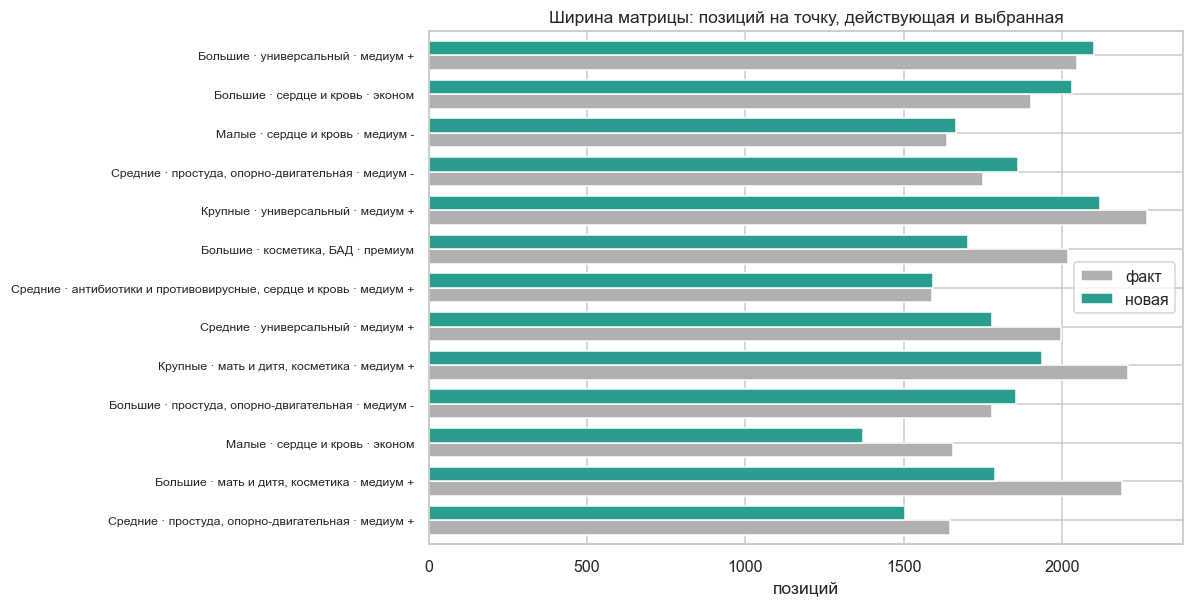

In [13]:
fact_width = fact_pairs.assign(grp=fact_pairs.TradePointId.map(seg_groups)).groupby('grp').size() / n_stores
width = pd.DataFrame({'факт': fact_width, 'новая': cand[cand[selected]].groupby('grp').size()}).loc[n_stores.sort_values().index]
ax = width.plot.barh(figsize=(11, 0.32 * len(width) + 1.5), color=['#b0b0b0', '#2a9d8f'], width=.75)
ax.set(title='Ширина матрицы: позиций на точку, действующая и выбранная', xlabel='позиций', ylabel='')
ax.tick_params(axis='y', labelsize=8); plt.tight_layout(); plt.show()

## Проверка на отложенных неделях

Выбор варианта сделан по тем же неделям, по которым считался Score, - такая оценка оптимистична: матрица
подстраивается под случайные всплески продаж. Честная оценка - на неделях, которых расчёт не видел: матрицы
фиксируются, и по реальным продажам второй половины периода считается, сколько они заработали бы.

Заодно сравниваются **способы разбить сеть на группы**. Процедура везде одна (Score, ABC, шкала строгости из 30 вариантов, выбор по правилу на неделях обучения),
меняется только разбиение. Для каждого способа строится кривая «остатки -> прибыль на отложенных неделях»:

- **одна матрица на сеть** - нижняя планка: сегментация должна давать больше;
- **категории A-E** - как сейчас в сети: по площади точки;
- **автосегменты** - результат кластеризации;
- **архетипы** - скрытая структура, заложенная в синтетические данные;
- **случайные группы** того же размера, что автосегменты (среднее по нескольким разбиениям) - проверка, что
  выигрыш даёт смысл групп, а не сам факт деления на мелкие группы.

In [14]:
rng = np.random.default_rng(SEED)
groupings = {
    'Одна матрица на сеть': pd.Series('сеть', index=stores.index),
    'Категории A-E': stores.CurrentCategory,
    'Автосегменты': stores.segment,
    'Архетипы': stores.archetype,
}
for i in range(N_RANDOM):
    groupings[f'Случайные группы #{i + 1}'] = pd.Series(rng.permutation(stores.segment.to_numpy()), index=stores.index)

fact_test = evaluate(fact_pairs, test)
rows, curve = [], []
for name, groups in groupings.items():
    c, _ = build_candidates(groups)
    rt = compare_variants(groups, c, train)
    v = choose(rt)
    # кривая «остатки -> прибыль»: вся шкала строгости, прибыль - и на обучении, и на отложенных неделях
    for vname in EXP_VARIANTS:
        tr = rt.set_index('вариант').loc[vname]
        te = evaluate(to_pairs(groups, c, vname), test)
        curve.append({'способ': name, 'вариант': vname, 'lam': dict(VARIANTS)[vname],
                      'Δ остатки': tr.diff_stock_rub, 'Δ прибыль, обучение': tr.diff_profit,
                      'Δ прибыль, проверка': te['profit'] - fact_test['profit'], 'выбран': vname == v})
    chosen_train = rt.set_index('вариант').loc[v]
    ev = evaluate(to_pairs(groups, c, v), test)
    rows.append({'способ': name, 'групп': groups.nunique(), 'вариант': v,
                 'позиций на точку': ev['positions'],
                 'Δ остатки': chosen_train.diff_stock_rub,
                 'Δ прибыль, обучение': chosen_train.diff_profit,
                 'Δ выручка, проверка': ev['revenue'] - fact_test['revenue'],
                 'Δ прибыль, проверка': ev['profit'] - fact_test['profit']})
exp = pd.DataFrame(rows)

# случайные разбиения - одной строкой (среднее), разброс - отдельно
rnd = exp[exp['способ'].str.startswith('Случайные')]
rnd_row = rnd.mean(numeric_only=True).to_dict()
rnd_row.update({'способ': 'Случайные группы', 'вариант': f'среднее по {N_RANDOM}'})
summary = pd.concat([exp[~exp['способ'].str.startswith('Случайные')], pd.DataFrame([rnd_row])], ignore_index=True)
# одно число: прибыль на проверке минус стоимость денег в остатках за период проверки
summary['эффект'] = summary['Δ прибыль, проверка'] - summary['Δ остатки'] * CAPITAL_COST_YEAR * TEST_DAYS / 365

# кривые: случайные разбиения усредняются по каждому λ
frontier = pd.DataFrame(curve)
is_rnd = frontier['способ'].str.startswith('Случайные')
rnd_curve = frontier[is_rnd].groupby(['вариант', 'lam'], as_index=False)[['Δ остатки', 'Δ прибыль, обучение', 'Δ прибыль, проверка']].mean()
rnd_curve['способ'], rnd_curve['выбран'] = 'Случайные группы', False
frontier = pd.concat([frontier[~is_rnd], rnd_curve], ignore_index=True).sort_values(['способ', 'lam'])
print(f"Случайные группы: Δ прибыль на проверке от {rnd['Δ прибыль, проверка'].min() / 1e6:+.1f} "
      f"до {rnd['Δ прибыль, проверка'].max() / 1e6:+.1f} млн ₽")
summary.style.format({c: '{:,.0f}' for c in summary.columns if c not in ('способ', 'вариант')})

Случайные группы: Δ прибыль на проверке от +1.1 до +1.5 млн ₽


,способ,групп,вариант,позиций на точку,Δ остатки,"Δ прибыль, обучение","Δ выручка, проверка","Δ прибыль, проверка",эффект
0,Одна матрица на сеть,1,экспоненциальный (λ=0.46),"1,802","-10,323,524","-7,435,163","-28,591,958","-7,646,373","-7,487,985"
1,Категории A-E,5,экспоненциальный (λ=0.32),"1,820","-8,891,935","-222,798","-1,290,801","-632,204","-495,780"
2,Автосегменты,13,экспоненциальный (λ=0.15),"1,861","-341,959","9,300,609","31,891,603","7,648,809","7,654,056"
3,Архетипы,8,экспоненциальный (λ=0.22),"1,843","-1,782,687","5,400,687","19,442,256","4,603,005","4,630,356"
4,Случайные группы,13,среднее по 5,"1,786","-17,260,747","2,724,984","6,674,634","1,342,912","1,607,734"


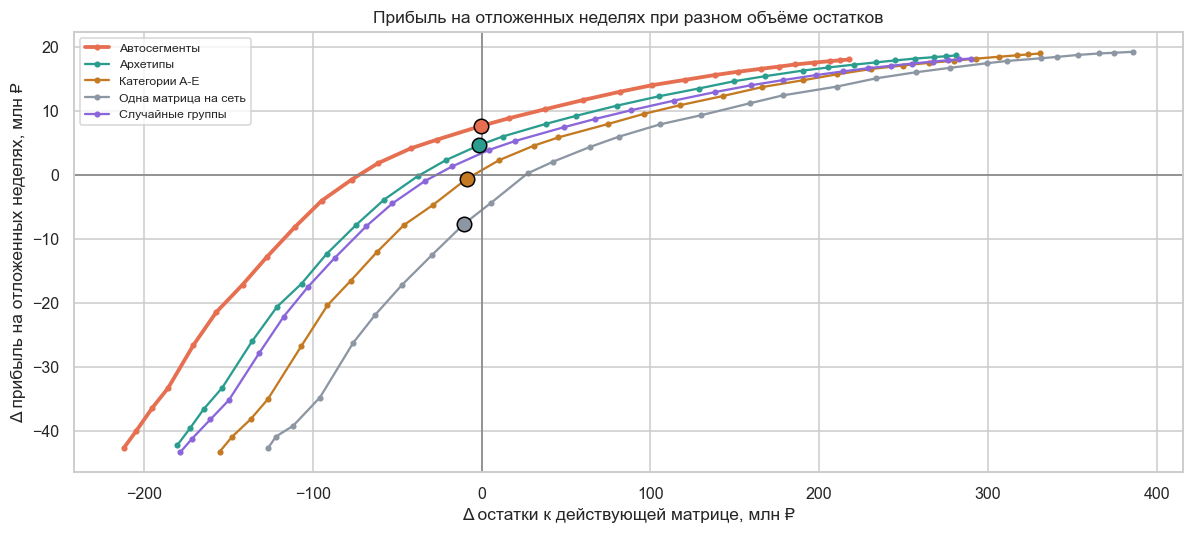

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
palette = {'Одна матрица на сеть': '#8d97a3', 'Категории A-E': '#c47a22', 'Автосегменты': '#e76f51',
           'Архетипы': '#2a9d8f', 'Случайные группы': '#8a66da'}
for name, g in frontier.groupby('способ'):
    g = g.sort_values('Δ остатки')
    ax.plot(g['Δ остатки'] / 1e6, g['Δ прибыль, проверка'] / 1e6, marker='o', ms=3, color=palette.get(name), label=name,
            lw=2.5 if name == 'Автосегменты' else 1.5)
    chosen = g[g['выбран']]
    ax.scatter(chosen['Δ остатки'] / 1e6, chosen['Δ прибыль, проверка'] / 1e6, s=90, color=palette.get(name),
               edgecolor='black', zorder=5)
ax.axhline(0, color='grey', lw=1); ax.axvline(0, color='grey', lw=1)
ax.set(title='Прибыль на отложенных неделях при разном объёме остатков', xlabel='Δ остатки к действующей матрице, млн ₽',
       ylabel='Δ прибыль на отложенных неделях, млн ₽')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

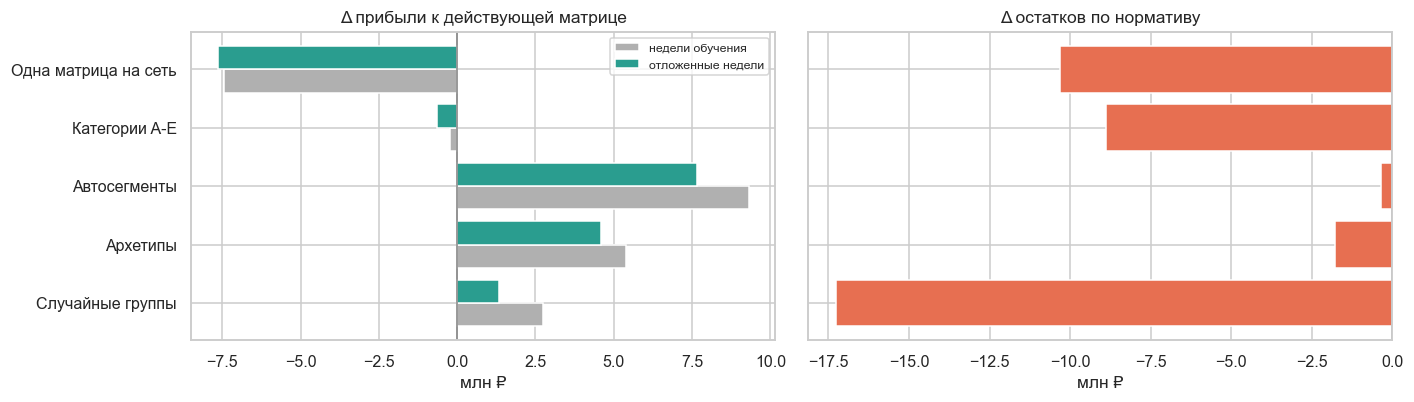

In [16]:
order = summary.set_index('способ')
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
y = np.arange(len(order))
axes[0].barh(y + 0.2, order['Δ прибыль, обучение'] / 1e6, height=0.4, color='#b0b0b0', label='недели обучения')
axes[0].barh(y - 0.2, order['Δ прибыль, проверка'] / 1e6, height=0.4, color='#2a9d8f', label='отложенные недели')
axes[0].set_yticks(y); axes[0].set_yticklabels(order.index); axes[0].invert_yaxis(); axes[0].axvline(0, color='grey', lw=1)
axes[0].set(title='Δ прибыли к действующей матрице', xlabel='млн ₽'); axes[0].legend(fontsize=8)
axes[1].barh(y, order['Δ остатки'] / 1e6, color='#e76f51')
axes[1].set_yticks(y); axes[1].set_yticklabels([]); axes[1].invert_yaxis(); axes[1].axvline(0, color='grey', lw=1)
axes[1].set(title='Δ остатков по нормативу', xlabel='млн ₽')
plt.tight_layout(); plt.show()

### Сохранение результатов

In [17]:
def save(frame: pd.DataFrame, table: str):
    con.execute('CREATE SCHEMA IF NOT EXISTS results')
    con.register('tmp_df', frame)
    con.execute(f'CREATE OR REPLACE TABLE results.{table} AS SELECT * FROM tmp_df')
    con.unregister('tmp_df')


final_matrix = cand[cand[selected]].join(products[['name']], on='apCode')[['grp', 'apCode', 'name', 'Unit', 'Status', 'score', 'score_norm_ap']]
save(final_matrix.rename(columns={'grp': 'segment'}), 'assortment_matrix')

# агрегаты для графиков на сайте
save(units[['grp', 'Unit', 'score_unit', 'share_by_cluster', 'cum_share', 'Status']].rename(columns={'grp': 'segment'}), 'scoring_units')
variants = res_train.rename(columns={'вариант': 'variant', 'positions': 'positions', 'diff_positions': 'diff_positions'})
variants['selected'] = variants.variant == selected
save(variants, 'scoring_variants')
save(width.reset_index().rename(columns={'index': 'segment', 'grp': 'segment', 'факт': 'fact', 'новая': 'new'})
     .merge(n_stores.rename('n_stores'), left_on='segment', right_index=True), 'scoring_width')
save(summary.rename(columns={'способ': 'method', 'групп': 'groups', 'вариант': 'variant', 'позиций на точку': 'positions',
                             'Δ остатки': 'd_stock', 'Δ прибыль, обучение': 'd_profit_train',
                             'Δ выручка, проверка': 'd_revenue_test', 'Δ прибыль, проверка': 'd_profit_test',
                             'эффект': 'effect'}), 'scoring_experiment')
save(frontier.rename(columns={'способ': 'method', 'вариант': 'variant', 'Δ остатки': 'd_stock',
                              'Δ прибыль, обучение': 'd_profit_train', 'Δ прибыль, проверка': 'd_profit_test',
                              'выбран': 'selected'}), 'scoring_frontier')
save(pd.DataFrame([('train_days', TRAIN_DAYS), ('test_days', TEST_DAYS), ('display_units', DISPLAY_UNITS),
                   ('lead_days', LEAD_DAYS), ('review_days', REVIEW_DAYS), ('service_z', SERVICE_Z),
                   ('capital_cost_year', CAPITAL_COST_YEAR), ('n_random', N_RANDOM),
                   ('fact_stock_rub', fact_train.stock_rub), ('fact_profit_train', fact_train.profit),
                   ('fact_revenue_train', fact_train.revenue), ('fact_profit_test', fact_test['profit']),
                   ('fact_positions', fact_train.positions)], columns=['param', 'value']), 'scoring_params')
con.close()
print(f'results.assortment_matrix: {len(final_matrix):,} строк')

results.assortment_matrix: 23,312 строк


## Отличия от оригинального расчёта

- **Score считается по продажам** сегмента (выручка на точку с поправкой на ценовой уровень); в оригинале Score
  брался из отдельного расчёта.
- **Юниты** построены из справочника: МНН + лекарственная форма + категория фасовки (пачка на 10 и на 100
  таблеток - разные юниты); в оригинале - готовый справочник юнитов.
- **Остатки считаются по нормативу запаса** для каждой пары «точка × товар», а не по фактическому остатку:
  так видно, сколько денег замораживает каждый вариант матрицы.
- **Деньги считаются по точкам**: у каждой точки своя матрица (её сегмента) и свои продажи.
- **Защищённые позиции** (минимальный ассортимент, СТМ) включены как переключаемая опция.
- **Переключение спроса**: при исключении товара половина его продаж переходит на аналоги из того же юнита.
- **Выбор варианта формализован** (максимум прибыли без роста остатков) и идёт по плавной шкале строгости из
  30 значений вместо ручного выбора из нескольких вариантов по графику.
- **Добавлена проверка на отложенных неделях** и сравнение способов сегментации - в оригинале такой проверки не было.